# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2025**


----

# Trabajo práctico entregable - parte 2


Grupo 26: Astoreca Pablo, Callen Ailen, Mendez Juan y Zamorano Micaela.

Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
sns.set_context('talk')

In [2]:
# Acá deberían leer el conjunto de datos que ya tienen.
melb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`, que volveremos a imputar más adelante.


Creamos un nuevo dataframe sin las columnas BuildingArea y YearBuilt.

Ademas, dentro de las variables categoricas presentes en el dataframe eliminamos las columnas de Address, CouncilArea y Suburb. Esta decision se debe a que las tres columnas presentan muchos datos unicos lo que implicaria que al realizar el OneHotEncoding obtendriamos un dataframe con muchas columnas. Por otro lado, dejamos la columna Regionname y Postcode que nos da una informacion similar a las eliminadas. Por lo que estamos achicando el costo de computo sin perder informacion.

In [3]:
df_melb = melb_df.drop(columns=['BuildingArea', 'YearBuilt', 'Address','CouncilArea','Suburb'])

2. Aplicar una codificación One-hot encoding a cada fila, para variables categóricas. Si lo consideran necesario, pueden volver a reducir el número de categorías únicas.


In [4]:
df=df_melb.copy()

In [5]:
for column in df.columns:
  num_unique_entries = df[column].nunique()
  print(f' {column} --> {num_unique_entries} entradas diferentes')

 Rooms --> 9 entradas diferentes
 Type --> 3 entradas diferentes
 Price --> 2204 entradas diferentes
 Method --> 5 entradas diferentes
 SellerG --> 268 entradas diferentes
 Date --> 58 entradas diferentes
 Distance --> 202 entradas diferentes
 Postcode --> 198 entradas diferentes
 Bedroom2 --> 12 entradas diferentes
 Bathroom --> 9 entradas diferentes
 Car --> 11 entradas diferentes
 Landsize --> 1448 entradas diferentes
 Lattitude --> 6503 entradas diferentes
 Longtitude --> 7063 entradas diferentes
 Regionname --> 8 entradas diferentes
 Propertycount --> 311 entradas diferentes


Dentro de las variables categoricas seleccionadas: Type, Method, SellerG y Regionname vemos que la columna SellerG es la que mas valores unicos tiene (268 entradas diferentes) por lo que solamente nos vamos a quedar con los 20 vendedores mas frecuentes y al resto los incluiremos dentro de la categoria 'Otros'.

Por otro lado, podemos incluir la fecha como una variable categórica en el proceso de codificación (encoding). Aunque la fecha es un dato numérico, actualmente la tenemos almacenada como un objeto de tipo DateTime. Para reducir la cantidad de categorías posibles, podemos extraer únicamente el año, lo cual nos da una nueva columna 'Date_year' de tipo objeto. Esta columna será incorporada al conjunto de variables categóricas para el encoding.

In [6]:
top_seller = df['SellerG'].value_counts().nlargest(20).index
df['SellerG_grouped'] = df['SellerG'].apply(lambda x: x if x in top_seller else 'Otros')

df["Date_year"] = pd.to_datetime(df["Date"], errors="coerce", format="%d/%m/%Y").dt.strftime("%Y")

Una vez agrupadas las variables, vamos a definir un nuevo dataframe con estas nuevas columnas.

In [7]:
df_reduced = df[['Date_year', 'Type', 'Method', 'Regionname', 'SellerG_grouped',
                  'Car','Bathroom','Bedroom2','Rooms', 'Landsize', 'Lattitude', 'Longtitude',
                 'Propertycount', 'Distance','Postcode','Price']]


A continuacion podemos ver que en este nuevo dataframe el numero de entras unicas en cada variable categorica no supera en ningun caso las 25 entradas

In [8]:
for column in df_reduced.columns:
  num_unique_entries = df_reduced[column].nunique()
  print(f' {column} --> {num_unique_entries} entradas diferentes')

 Date_year --> 2 entradas diferentes
 Type --> 3 entradas diferentes
 Method --> 5 entradas diferentes
 Regionname --> 8 entradas diferentes
 SellerG_grouped --> 21 entradas diferentes
 Car --> 11 entradas diferentes
 Bathroom --> 9 entradas diferentes
 Bedroom2 --> 12 entradas diferentes
 Rooms --> 9 entradas diferentes
 Landsize --> 1448 entradas diferentes
 Lattitude --> 6503 entradas diferentes
 Longtitude --> 7063 entradas diferentes
 Propertycount --> 311 entradas diferentes
 Distance --> 202 entradas diferentes
 Postcode --> 198 entradas diferentes
 Price --> 2204 entradas diferentes


Para aplicar el encoding vamos a utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.

Entonces como primer paso dividimos nuestro dataframe en variables numericas (num_cols) y categoricas (cat_cols) y luego aplicarlo solamente a las columnas dentro de cat_cols

In [9]:
cat_cols = df_reduced.select_dtypes(include='object').columns
num_cols = df_reduced.select_dtypes(include=np.number).columns

In [10]:
from sklearn.preprocessing import OneHotEncoder


# Inicializar codificador
encoder_cat = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


# Aplicar codificación a categóricas
encoded_cat = encoder_cat.fit_transform(df_reduced[cat_cols])
encoded_cat_cols = encoder_cat.get_feature_names_out(cat_cols)
df_encoded_cat = pd.DataFrame(encoded_cat, columns=encoded_cat_cols, index=df_reduced.index)


# Concatenar con las numericas usando numpyhstack
df_numeric = df_reduced[num_cols]
combined_array = np.hstack([df_numeric.values, df_encoded_cat.values])

# Crear un nuevo DataFrame con todas las columnas
combined_cols = list(num_cols) + list(encoded_cat_cols)
df_final = pd.DataFrame(combined_array, columns=combined_cols, index=df_reduced.index)


Una vez aplicado el encoding, concatenamos las variables categoricas con las numericas y convertimos todo en un nuevo dataframe llamado df_final. Como vemos a continuacion posee 50 columnas y las 13580 filas iniciales.

In [11]:
df_final

,Car,Bathroom,Bedroom2,Rooms,Landsize,Lattitude,Longtitude,Propertycount,Distance,Postcode,...,SellerG_grouped_McGrath,SellerG_grouped_Miles,SellerG_grouped_Nelson,SellerG_grouped_Noel,SellerG_grouped_Otros,SellerG_grouped_RT,SellerG_grouped_Ray,SellerG_grouped_Sweeney,SellerG_grouped_Woodards,SellerG_grouped_hockingstuart
0,1.0,1.0,2.0,2.0,202.0,-37.79960,144.99840,4019.0,2.5,3067.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,2.0,2.0,156.0,-37.80790,144.99340,4019.0,2.5,3067.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,2.0,3.0,3.0,134.0,-37.80930,144.99440,4019.0,2.5,3067.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,2.0,3.0,3.0,94.0,-37.79690,144.99690,4019.0,2.5,3067.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2.0,1.0,3.0,4.0,120.0,-37.80720,144.99410,4019.0,2.5,3067.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,2.0,2.0,4.0,4.0,652.0,-37.90562,145.16761,7392.0,16.7,3150.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13576,2.0,2.0,3.0,3.0,333.0,-37.85927,144.87904,6380.0,6.8,3016.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
13577,4.0,2.0,3.0,3.0,436.0,-37.85274,144.88738,6380.0,6.8,3016.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
13578,5.0,1.0,4.0,4.0,866.0,-37.85908,144.89299,6380.0,6.8,3016.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Al hacer el encoding pasamos a tener todas las variables en formato float64 (número) lo que nos permite ahora si aplicar el algoritmo KNN para imputar los datos faltantes en ciertas columnas

## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer` para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

In [12]:
#Agregar las columnas yearbuilt y buildingarea al encoded_df
df_final['YearBuilt'] = melb_df['YearBuilt']
df_final['BuildingArea'] = melb_df['BuildingArea']

In [13]:
df_final.isna().sum()[df_final.isna().sum() > 0]

,0
Car,62
YearBuilt,5375
BuildingArea,6450


Antes de imputar con KNN podemos asumir que para los valores nulos de Car significa que no tienen cochera, por lo que le asignamos el valor cero.

In [14]:
df_final['Car'] = df_final['Car'].fillna(0)

Como KNN se basa en medir distancias, es importante escalar los datos ya qye YearBuilt y BuildingArea tienen diferentes magnitudes. Para ello, vamos a utilizar el paquete StandarScaler de scikit-learn, que al aplicarlo los datos escalados tienen media cero y sigma 1.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

# Copia del df original
melb_data_mice = df_final.copy(deep=True)

# Escalador

scaler = StandardScaler()
melb_scaled = scaler.fit_transform(melb_data_mice)

#knn
mice_imputer = IterativeImputer(random_state=0, estimator=KNeighborsRegressor())
# Imputar (el output también estará escalado)
imputed_scaled = mice_imputer.fit_transform(melb_scaled)

# Invertir el escalado para tener valores en escala original
imputed = scaler.inverse_transform(imputed_scaled)

# Crear DataFrame con las columnas originales y mismo índice
df_imputed_scaled = pd.DataFrame(imputed, columns=df_final.columns, index=df_final.index)

/usr/local/lib/python3.11/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Ahora podemos chequear que los datos fueron imputados al comprobar que no hay columnas con valores nulos

In [16]:
df_imputed_scaled.isna().sum()[df_imputed_scaled.isna().sum() > 0]

,0


## Prueba sin escalado ##

In [17]:
melb_data_mice = df_final.copy(deep=True)

mice_imputer = IterativeImputer(random_state=0, estimator=KNeighborsRegressor())
imputed = mice_imputer.fit_transform(melb_data_mice) #uso todas las columnas para imputar

# Creamos un nuevo DataFrame con las columnas imputadas
df_imputed = pd.DataFrame(imputed, columns=df_final.columns, index=df_final.index)


Una manera de chequear que la imputacion de los datos mantenga la estructura de la distribucion de los datos es realizar un KDE ('kernel density estimation') con los datos antes y despues de la imputacion. Como podemos ver a continuacion, los datos imputados siguen bastante bien los datos reales.

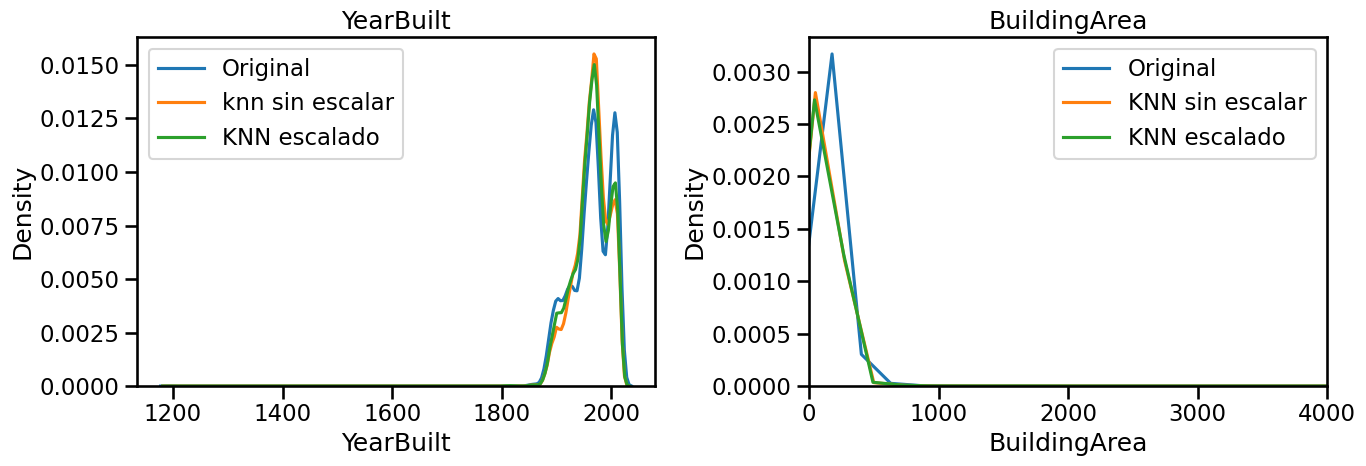

In [18]:
# === 3. Datos originales (sin NaNs)
yearbuilt_orig = df_final['YearBuilt'].dropna()
buildingarea_orig = df_final['BuildingArea'].dropna()

# === 4. Crear figura y subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: YearBuilt ---
sns.kdeplot(x=yearbuilt_orig, label='Original', ax=axes[0])
sns.kdeplot(x=df_imputed['YearBuilt'], ax=axes[0], label='knn sin escalar')
sns.kdeplot(x=df_imputed_scaled['YearBuilt'], label='KNN escalado', ax=axes[0])

axes[0].set_title('YearBuilt')
axes[0].legend()

# --- Subplot 2: BuildingArea ---
sns.kdeplot(x=buildingarea_orig, label='Original', ax=axes[1])
sns.kdeplot(x=df_imputed['BuildingArea'], label='KNN sin escalar', ax=axes[1])
sns.kdeplot(x=df_imputed_scaled['BuildingArea'], label='KNN escalado', ax=axes[1])
axes[1].set_title('BuildingArea')
axes[1].legend()
axes[1].set_xlim(0, 4000)

plt.tight_layout()
plt.show()

En el caso de la antiguedad de las casas, al escalar los valores quedan mas cercanos al original mostrando la esencia del procedimiento realizado.

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos?

 Es necesario escalar antes de aplicar PCA, porque PCA está basado en la varianza de las variables, y si las columnas tienen escalas muy distintas (por ejemplo, años vs metros cuadrados), las variables con mayor varianza dominarán los componentes principales.

En este ejercicio comparamos el resultado de aplicar PCA con los datos procesados mediante StandardScaler y MinMaxScaler. Luego graficamos las dos primeras componentes de cada uno y analizamos sus diferencias.

In [19]:
# Empezamos desde el DataFrame imputado con KNN
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
X = df_imputed_scaled.copy()

Como fui conviertiendo y trabajando con dataframes durante todo el proceso, el archivo final processed_melb_df ya es un pandas df con todas las columnas trabajadas. Las numericas, las categoricas codificadas con el OneHot encoding, YearBuilt y BuildingArea imputadas con el metodo KNN y las dos primeras componentes del PCA

In [20]:
# Número de componentes principales
n_components = min(20, X.shape[0])

# --- StandardScaler ---
scaler_ss = StandardScaler()
X_scaled_ss = scaler_ss.fit_transform(X)
pca_ss = PCA(n_components=n_components)
X_pca_full_ss = pca_ss.fit_transform(X_scaled_ss)
X_pca_2_ss = X_pca_full_ss[:, :2]
X_augmented_ss = np.hstack([X.values, X_pca_2_ss])
columns_ss = list(X.columns) + ['pca1_ss', 'pca2_ss']
processed_ss_df = pd.DataFrame(X_augmented_ss, columns=columns_ss, index=X.index)

# --- MinMaxScaler ---
scaler_mms = MinMaxScaler()
X_scaled_mms = scaler_mms.fit_transform(X)
pca_mms = PCA(n_components=n_components)
X_pca_full_mms = pca_mms.fit_transform(X_scaled_mms)
X_pca_2_mms = X_pca_full_mms[:, :2]
X_augmented_mms = np.hstack([X.values, X_pca_2_mms])
columns_mms = list(X.columns) + ['pca1_mms', 'pca2_mms']
processed_mms_df = pd.DataFrame(X_augmented_mms, columns=columns_mms, index=X.index)

<ipython-input-21-11a2b0c75da2>:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


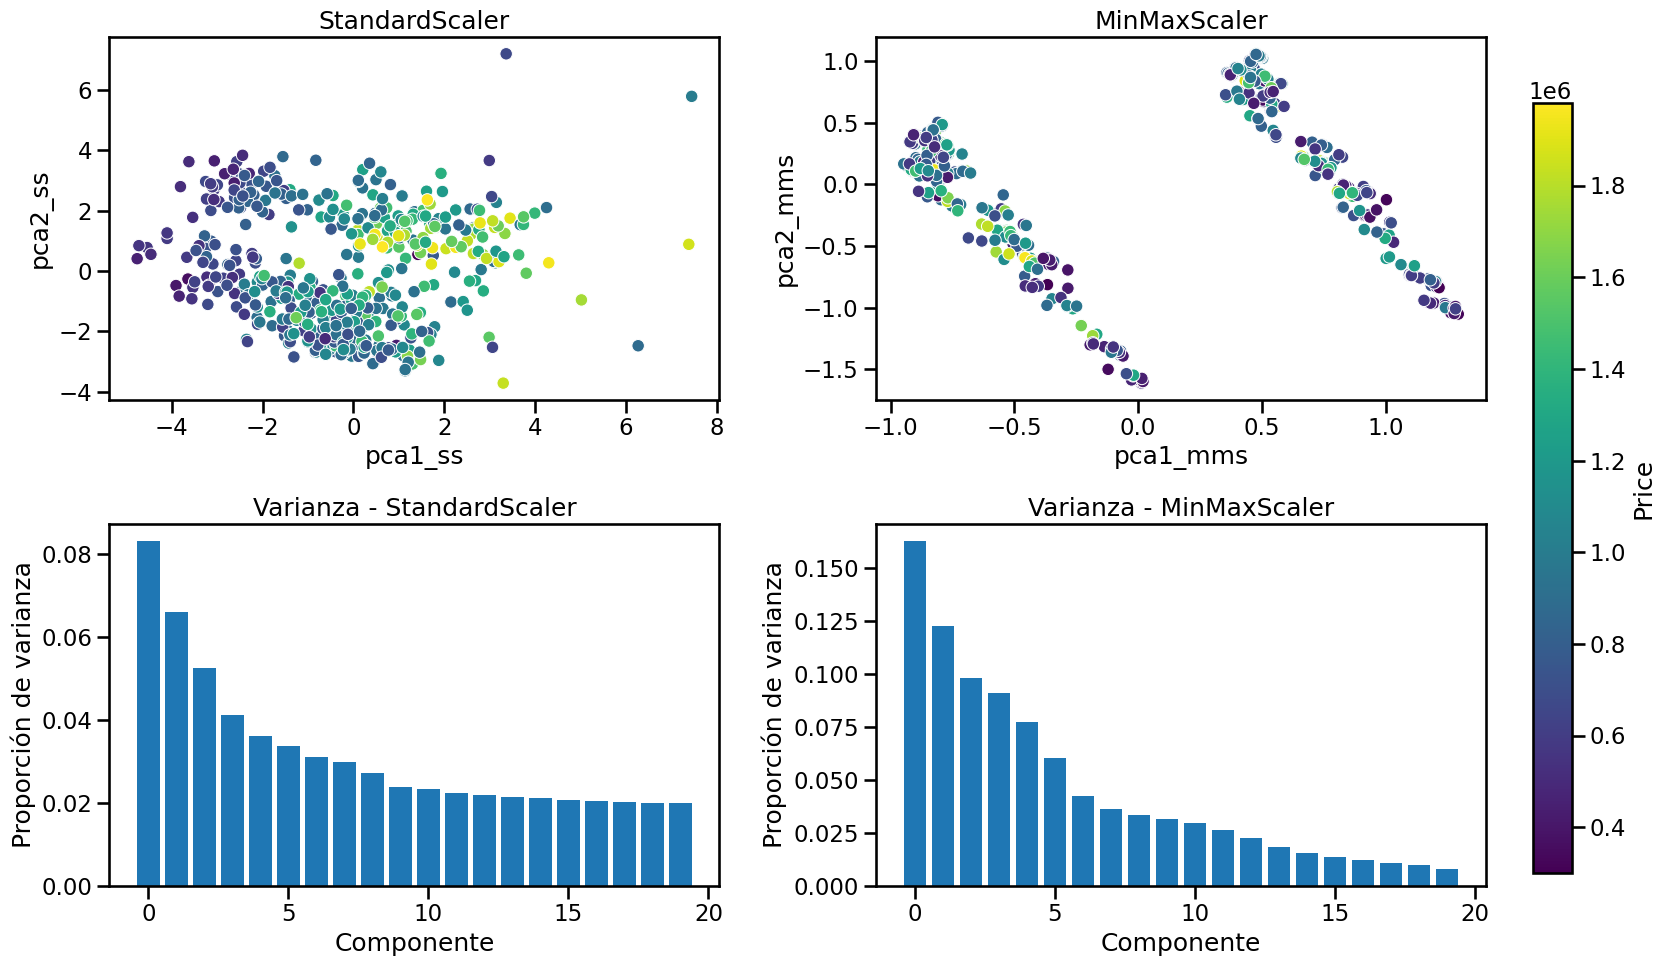

In [21]:
import matplotlib as mpl

# Subsamplear los datos para hacer más liviano el gráfico
data_ss = processed_ss_df[processed_ss_df.Price < 2_000_000].sample(500).reset_index(drop=True)
data_mms = processed_mms_df[processed_mms_df.Price < 2_000_000].sample(500).reset_index(drop=True)

# Crear figura de 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(18, 10))

# --- SCATTERPLOTS (primera fila) ---

# StandardScaler
sns.scatterplot(
    data=data_ss, x='pca1_ss', y='pca2_ss', hue='Price',
    ax=axs[0, 0], legend=False, palette='viridis'
)
axs[0, 0].set_title('StandardScaler')

# MinMaxScaler
sns.scatterplot(
    data=data_mms, x='pca1_mms', y='pca2_mms', hue='Price',
    ax=axs[0, 1], legend=False, palette='viridis'
)
axs[0, 1].set_title('MinMaxScaler')

# --- BARRAS DE VARIANZA (segunda fila) ---

# Varianza explicada - StandardScaler
axs[1, 0].bar(range(len(pca_ss.explained_variance_ratio_)), pca_ss.explained_variance_ratio_)
axs[1, 0].set_title('Varianza - StandardScaler')
axs[1, 0].set_xlabel('Componente')
axs[1, 0].set_ylabel('Proporción de varianza')

# Varianza explicada - MinMaxScaler
axs[1, 1].bar(range(len(pca_mms.explained_variance_ratio_)), pca_mms.explained_variance_ratio_)
axs[1, 1].set_title('Varianza - MinMaxScaler')
axs[1, 1].set_xlabel('Componente')
axs[1, 1].set_ylabel('Proporción de varianza')

# --- COLORBAR para el precio ---

norm = mpl.colors.Normalize(vmin=min(data_mms.Price), vmax=max(data_mms.Price))
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

# Agregar la colorbar
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('Price')

# Ajustar diseño para que no se superpongan los ejes ni la colorbar
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


En este caso se puede ver una clara diferencia al aplicar PCA despues de haber utilizado el StandardScaler o el MinMaxScaler. Con el MinMaxScaler podemos observar que las dos primeras componentes siguen un claro patron. En cambio, en el caso que usamos el StandardScaler podemos observar que las dos primeras componentes no siguen un patron tan marcado como en el caso anterior, pero nos damos cuenta que a grandes rasgos los precios van aumentando a medida que la primer componente va creciendo.

Tambien, viendo los graficos que se encuentran en la parte inferior, observamos que las dos primeras componentes principales despues de haber aplicado MinMaxScaler explican aproximadamente el doble de la varianza si la comparamos con las respectivas componentes principales del StandarScaler.

## Ejercicio 4: Composición del resultado

Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

Para eso, será necesario recordar el nombre original de cada columna de la matriz, en el orden correcto. Tener en cuenta:
1. El método `OneHotEncoder.get_feature_names` o el atributo `OneHotEncoder.categories_` permiten obtener una lista con los valores de la categoría que le corresponde a cada índice de la matriz.
2. Ninguno de los métodos aplicados intercambia de lugar las columnas o las filas de la matriz.

Este procedimiento se fue realizando step-by-step en cada actividad, iniciando con el dataframe crudo y terminando con el mostrado aqui abajo.
Cabe resaltar que:

1- Se realiza el encoding para transformar categoricas en numericas ya que es necesario para la imputacion por vecinos

2- Se realiza la imputacion para no dejar nulos. Esto es indispensable para el PCA.

In [22]:
processed_mms_df = pd.DataFrame(X_augmented_mms, columns=columns_mms, index=X.index)
processed_mms_df

,Car,Bathroom,Bedroom2,Rooms,Landsize,Lattitude,Longtitude,Propertycount,Distance,Postcode,...,SellerG_grouped_Otros,SellerG_grouped_RT,SellerG_grouped_Ray,SellerG_grouped_Sweeney,SellerG_grouped_Woodards,SellerG_grouped_hockingstuart,YearBuilt,BuildingArea,pca1_mms,pca2_mms
0,1.0,1.0,2.0,2.0,202.0,-37.79960,144.99840,4019.0,2.5,3067.0,...,-2.775558e-17,0.0,0.0,0.0,0.0,0.0,1921.0,77.60,0.494754,0.900221
1,0.0,1.0,2.0,2.0,156.0,-37.80790,144.99340,4019.0,2.5,3067.0,...,-2.775558e-17,0.0,0.0,0.0,0.0,0.0,1900.0,79.00,0.497130,0.897555
2,0.0,2.0,3.0,3.0,134.0,-37.80930,144.99440,4019.0,2.5,3067.0,...,-2.775558e-17,0.0,0.0,0.0,0.0,0.0,1900.0,150.00,-0.735562,0.146803
3,1.0,2.0,3.0,3.0,94.0,-37.79690,144.99690,4019.0,2.5,3067.0,...,-2.775558e-17,0.0,0.0,0.0,0.0,0.0,1918.6,110.54,-0.703783,0.127392
4,2.0,1.0,3.0,4.0,120.0,-37.80720,144.99410,4019.0,2.5,3067.0,...,-2.775558e-17,0.0,0.0,0.0,0.0,0.0,2014.0,142.00,0.568057,0.808404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,2.0,2.0,4.0,4.0,652.0,-37.90562,145.16761,7392.0,16.7,3150.0,...,-2.775558e-17,0.0,0.0,0.0,0.0,0.0,1981.0,177.00,-0.861283,0.152713
13576,2.0,2.0,3.0,3.0,333.0,-37.85927,144.87904,6380.0,6.8,3016.0,...,1.000000e+00,0.0,0.0,0.0,0.0,0.0,1995.0,133.00,-0.847425,0.120552
13577,4.0,2.0,3.0,3.0,436.0,-37.85274,144.88738,6380.0,6.8,3016.0,...,1.000000e+00,0.0,0.0,0.0,0.0,0.0,1997.0,190.60,-0.907660,0.328115
13578,5.0,1.0,4.0,4.0,866.0,-37.85908,144.89299,6380.0,6.8,3016.0,...,-2.775558e-17,0.0,0.0,1.0,0.0,0.0,1920.0,157.00,-0.746409,0.101702


## Ejercicio 5: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas
  2. Interpretación de las columnas presentes
  2. Todas las transofrmaciones realizadas

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```
